# Auto ARIMA Benchmark

Every automatic-ARIMA implementation available in Python, evaluated on the
M1 + M3 + Tourism competition series (5,315 in total) with the same harness and
metrics as the ETS and CES benchmarks: fit on `series.x`, forecast `series.h`
steps, score against `series.xx`.

**Metrics.** Point accuracy (**RMSSE**), **computational time**, and the
predictive distribution (**scaled pinball** loss and **calibration** at the 99
levels `seq(0.01, 0.99, 0.01)`). One fit per series produces the point forecast
*and* all 99 quantiles, so the timings cover the whole job a user would run.

**Compared here**

| Method | Package |
|---|---|
| `AutoMSARIMA(initial="backcasting")` | smooth |
| `AutoMSARIMA(initial="optimal")` | smooth |
| `AutoARIMA` | statsforecast |
| `Arima(order=None, seasonal_order=None)` | skforecast |

**Dropped, and why** — each reason is verified below rather than asserted:

- **sktime `AutoARIMA` — not an independent implementation.** It subclasses
  `_PmdArimaAdapter` and delegates to `pmdarima.arima.AutoARIMA`, so it returns
  pmdarima's forecasts exactly; its row would only duplicate the pmdarima row.
  It is therefore never fitted (cell below prints the class hierarchy that
  settles it).
- **pmdarima `auto_arima` — fails on part of the sample and is far too slow.**
  It is still *measured* here, so the exclusion is quantified rather than
  assumed: it errors out on a few dozen series and runs past the 120 s
  per-series budget on a few dozen more, which means it would be scored on a
  different sample than everything else, and its order search costs an order of
  magnitude more time per series than any other method (see the "excluded
  implementations" table).
- **aeon `AutoARIMA` — no seasonal ARIMA.** `aeon.forecasting.stats.AutoARIMA`
  takes no seasonal period and searches non-seasonal orders only, which cannot
  be compared fairly on a collection that is mostly seasonal. It also exposes
  no quantile or interval API at all, so it has no pinball loss and no
  calibration curve. Measured below for the record; excluded from the
  comparison.

The heavy fit+forecast run lives in `smooth-paper/run_full_benchmark.py`, which
also drives the ETS side of the paper. Set `BENCH_RERUN_ARIMA=1` to recompute;
otherwise the most recent saved arrays are loaded.

In [1]:
import glob, os, subprocess, sys
import numpy as np
import pandas as pd

pd.set_option("display.width", 220)
LEVELS = np.round(np.arange(0.01, 1.0, 0.01), 2)

HERE = os.getcwd()
PAPER = os.path.join(HERE, "smooth-paper")     # scripts + Data for the paper

## Versions

In [2]:
from importlib.metadata import version as pkg_version

print(f"python {sys.version.split()[0]}")
for _p in ("smooth", "numpy", "pandas", "statsforecast", "skforecast",
           "pmdarima", "aeon", "sktime", "fcompdata"):
    try:
        print(f"{_p:15s} v{pkg_version(_p)}")
    except Exception:
        print(f"{_p:15s} not installed")

python 3.14.4
smooth          v1.0.8
numpy           v2.3.5
pandas          v2.3.3
statsforecast   v2.1.1
skforecast      v0.23.0
pmdarima        v2.1.1
aeon            v1.5.0
sktime          v1.0.1
fcompdata       v0.1.4


## Why sktime is not a separate row

sktime's `AutoARIMA` is an adapter, not an implementation: the class hierarchy
ends in `_PmdArimaAdapter`, and the fitted object it holds is a
`pmdarima.arima.ARIMA`. Running it would reproduce the pmdarima row to the last
digit while paying the fitting cost twice.

In [3]:
import inspect
import warnings
warnings.filterwarnings("ignore")

from sktime.forecasting.arima import AutoARIMA as SktimeAutoARIMA

print("sktime AutoARIMA defined in:", inspect.getmodule(SktimeAutoARIMA).__name__)
print("class hierarchy:", " <- ".join(k.__name__ for k in SktimeAutoARIMA.__mro__[:4]))

import pmdarima as pm
_adapter = [k for k in SktimeAutoARIMA.__mro__ if k.__name__ == "_PmdArimaAdapter"][0]
print("\nthe adapter's module imports pmdarima:",
      "pmdarima" in inspect.getsource(inspect.getmodule(_adapter)))
print("pmdarima estimator used by sktime:", pm.arima.AutoARIMA.__module__ + ".AutoARIMA")

sktime AutoARIMA defined in: sktime.forecasting.arima._pmdarima
class hierarchy: AutoARIMA <- _PmdArimaAdapter <- BaseForecaster <- _PredictProbaMixin



the adapter's module imports pmdarima: True
pmdarima estimator used by sktime: pmdarima.arima.auto.AutoARIMA


## Why aeon is not a separate row

`aeon.forecasting.stats.AutoARIMA` has no seasonal period argument: it searches
`(p, d, q)` only. On M1 + M3 + Tourism, where most series are seasonal, that is
a different modelling problem, not a weaker search of the same one. It also has
no `predict_quantiles`/`predict_interval`, so there is nothing to score the
predictive distribution with.

In [4]:
from aeon.forecasting.stats import AutoARIMA as AeonAutoARIMA

_params = list(inspect.signature(AeonAutoARIMA.__init__).parameters)[1:]
print("aeon AutoARIMA signature:", _params)
print("seasonal argument present:",
      any("season" in p or p in ("m", "sp") for p in _params))

_quantile_api = [a for a in dir(AeonAutoARIMA)
                 if "quantile" in a or "interval" in a or "proba" in a]
print("quantile / interval API:", _quantile_api or "none")

aeon AutoARIMA signature: ['max_p', 'max_d', 'max_q']
seasonal argument present: False
quantile / interval API: none


## Datasets

In [5]:
from fcompdata import M1, M3, Tourism

datasets = ([M1[k] for k in M1.keys()]
            + [M3[k] for k in M3.keys()]
            + [Tourism[k] for k in Tourism.keys()])

seasonal = sum(1 for s in datasets if s.period > 1)
print(f"M1: {len(M1)}   M3: {len(M3)}   Tourism: {len(Tourism)}   total: {len(datasets)}")
print(f"seasonal series (period > 1): {seasonal} "
      f"({100 * seasonal / len(datasets):.1f}% of the collection)")

M1: 1001   M3: 3003   Tourism: 1311   total: 5315
seasonal series (period > 1): 3797 (71.4% of the collection)


## Run or load

`run_full_benchmark.py` evaluates one method at a time and spreads the series
over a process pool, so per-series timings are comparable within a method. The
arrays it writes are:

- `{date}-benchmark-arima-point.npy` — `(methods, series, 3)`: RMSSE, seconds, timed-out flag
- `{date}-benchmark-arima-dist.npy` — `(methods, series, 99, 2)`: scaled pinball, coverage
- `{date}-benchmark-arima-methods.txt` — method names in array order

In [6]:
if os.environ.get("BENCH_RERUN_ARIMA", "0") == "1":
    import multiprocessing
    subprocess.run([sys.executable, "run_full_benchmark.py"], cwd=PAPER, check=True,
                   env=dict(os.environ, BENCH_KIND="arima",
                            BENCH_WORKERS=str(min(30, multiprocessing.cpu_count()))))


def latest(pattern):
    # Newest file matching `pattern` in this directory or in smooth-paper/.
    hits = glob.glob(os.path.join(HERE, pattern)) + glob.glob(os.path.join(PAPER, pattern))
    if not hits:
        raise FileNotFoundError(pattern)
    return sorted(hits, key=os.path.basename)[-1]


point_file, dist_file = latest("*-benchmark-arima-point.npy"), latest("*-benchmark-arima-dist.npy")
point = np.load(point_file)
dist = np.load(dist_file)
with open(latest("*-benchmark-arima-methods.txt")) as f:
    names = [line.rstrip("\n").split("\t")[0] for line in f if line.strip()]

print("point:", os.path.basename(point_file), point.shape)
print("dist :", os.path.basename(dist_file), dist.shape)
assert point.shape[0] == len(names) and point.shape[1] == len(datasets)

# Guard against scoring a stale run: arrays written before the last edit to the
# smooth sources describe a different package than the one imported above.
SRC = os.path.abspath(os.path.join(HERE, "..", "..", "src", "smooth"))
newest_source = max(os.path.getmtime(os.path.join(folder, f))
                    for folder, _, files in os.walk(SRC)
                    for f in files if f.endswith(".py"))
if os.path.getmtime(point_file) < newest_source:
    print("\nWARNING: the saved arrays predate the smooth sources; "
          "rerun with BENCH_RERUN_ARIMA=1")
else:
    print("\narrays postdate the smooth sources")

KEPT = ["AutoMSARIMA Back", "AutoMSARIMA Opt", "statsforecast AutoARIMA", "skforecast Arima"]
DROPPED = ["pmdarima auto_arima", "aeon AutoARIMA"]
row = {n: names.index(n) for n in names}
print("\nmethods in the arrays:", ", ".join(names))

point: 2026-09-21-benchmark-arima-point.npy (6, 5315, 3)
dist : 2026-09-21-benchmark-arima-dist.npy (6, 5315, 99, 2)



arrays postdate the smooth sources

methods in the arrays: AutoMSARIMA Back, AutoMSARIMA Opt, statsforecast AutoARIMA, pmdarima auto_arima, skforecast Arima, aeon AutoARIMA


## Point accuracy and computational time

In [7]:
def table(method_names, values, extra=None, label=""):
    # Five-number summary + mean of `values(j)` for each named method.
    frame = pd.DataFrame({
        "Method": method_names,
        "Min": [np.nanmin(values(row[n])) for n in method_names],
        "Q1": [np.nanquantile(values(row[n]), 0.25) for n in method_names],
        "Med": [np.nanmedian(values(row[n])) for n in method_names],
        "Q3": [np.nanquantile(values(row[n]), 0.75) for n in method_names],
        "Max": [np.nanmax(values(row[n])) for n in method_names],
        "Mean": [np.nanmean(values(row[n])) for n in method_names],
    })
    for name, fun in (extra or {}).items():
        frame[name] = [fun(row[n]) for n in method_names]
    print("\n" + "=" * 104 + f"\n{label}\n" + "=" * 104)
    print(frame.sort_values("Mean").to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    return frame


rmsse_summary = table(
    KEPT, lambda j: point[j, :, 0],
    extra={"Mean Time (s)": lambda j: np.nanmean(point[j, :, 1]),
           "Failed": lambda j: int(np.sum(np.isnan(point[j, :, 0])))},
    label=f"RMSSE, all {point.shape[1]} series (lower = better)")


RMSSE, all 5315 series (lower = better)
                 Method    Min     Q1    Med     Q3     Max   Mean  Mean Time (s)  Failed
statsforecast AutoARIMA 0.0246 0.6826 1.1849 2.3533 51.6160 1.9809         1.3597       0
       skforecast Arima 0.0246 0.6927 1.1914 2.3703 51.6160 1.9971         2.0991       0
       AutoMSARIMA Back 0.0246 0.6900 1.1828 2.3725 51.6160 2.0049         0.3346       0
        AutoMSARIMA Opt 0.0246 0.7186 1.2155 2.4329 51.6160 2.0323         1.5962       0


In [8]:
time_summary = table(
    KEPT, lambda j: point[j, :, 1],
    extra={"Total (min)": lambda j: np.nansum(point[j, :, 1]) / 60,
           "Timeouts": lambda j: int(np.nansum(point[j, :, 2]))},
    label=f"Computational time in seconds, all {point.shape[1]} series")


Computational time in seconds, all 5315 series
                 Method    Min     Q1    Med     Q3      Max   Mean  Total (min)  Timeouts
       AutoMSARIMA Back 0.0378 0.1514 0.2984 0.4267   2.7491 0.3346      29.6396         0
statsforecast AutoARIMA 0.0311 0.2736 0.5402 1.2872  70.1680 1.3597     120.4508         0
        AutoMSARIMA Opt 0.0915 0.3484 1.3106 2.4857   9.8108 1.5962     141.4000         0
       skforecast Arima 0.0277 0.3790 0.6861 1.8508 101.2417 2.0991     185.9452         0


## Predictive distribution: pinball loss and calibration

`MCE` is the mean calibration error: the average absolute gap between empirical
coverage and the nominal level, over the 99 levels. `Cov@0.1 / 0.5 / 0.9` are
the empirical coverages at those levels, where a perfectly calibrated method
returns the level itself.

In [9]:
pinball = dist[:, :, :, 0]                      # (methods, series, 99)
coverage = dist[:, :, :, 1]
pinball_series = np.nanmean(pinball, axis=2)    # (methods, series)

rows = []
for n in KEPT:
    j = row[n]
    curve = np.nanmean(coverage[j], axis=0)
    rows.append({"Method": n,
                 "Mean Pinball": np.nanmean(pinball[j]),
                 "Median Pinball": np.nanmedian(pinball_series[j]),
                 "MCE": np.nanmean(np.abs(curve - LEVELS)),
                 "Cov@0.1": curve[9], "Cov@0.5": curve[49], "Cov@0.9": curve[89],
                 "n": int(np.sum(np.isfinite(pinball_series[j])))})

dist_summary = pd.DataFrame(rows).sort_values("Median Pinball")
print("\n" + "=" * 104)
print("PREDICTIVE DISTRIBUTION: scaled pinball + calibration (lower = better)")
print("=" * 104)
print(dist_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


PREDICTIVE DISTRIBUTION: scaled pinball + calibration (lower = better)
                 Method  Mean Pinball  Median Pinball    MCE  Cov@0.1  Cov@0.5  Cov@0.9    n
statsforecast AutoARIMA        0.8883          0.4915 0.0357   0.1486   0.4830   0.8305 5315
       skforecast Arima        0.9000          0.4954 0.0392   0.1494   0.4801   0.8242 5315
       AutoMSARIMA Back        0.8961          0.4956 0.0326   0.1346   0.4769   0.8347 5315
        AutoMSARIMA Opt        0.9118          0.5083 0.0331   0.1315   0.4768   0.8315 5315


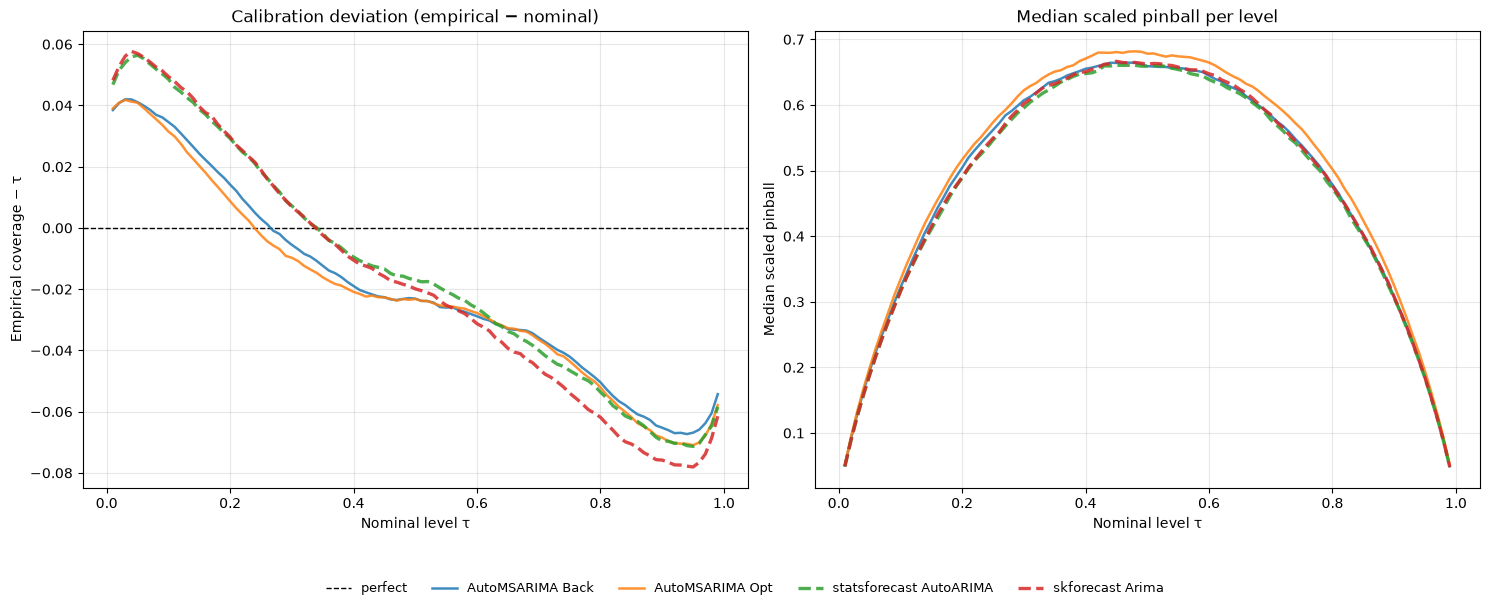

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ax[0].axhline(0.0, color="k", ls="--", lw=1, label="perfect")
for n in KEPT:
    j = row[n]
    smooth_row = n.startswith("AutoMSARIMA")
    style = dict(lw=1.8 if smooth_row else 2.4, ls="-" if smooth_row else "--", alpha=0.85, label=n)
    ax[0].plot(LEVELS, np.nanmean(coverage[j], axis=0) - LEVELS, **style)
    ax[1].plot(LEVELS, np.nanmedian(pinball[j], axis=0), **style)

ax[0].set(title="Calibration deviation (empirical − nominal)",
          xlabel="Nominal level τ", ylabel="Empirical coverage − τ")
ax[1].set(title="Median scaled pinball per level",
          xlabel="Nominal level τ", ylabel="Median scaled pinball")
for a in ax:
    a.grid(alpha=0.3)
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

## The excluded implementations, quantified

pmdarima and aeon were run alongside the others so that dropping them rests on
measurements. The table adds, for each, the number of series it could not fit,
its cost relative to the fastest smooth row, and whether it can produce
quantiles at all.

In [11]:
reference = np.nanmean(point[row["AutoMSARIMA Back"], :, 1])

rows = []
for n in KEPT + DROPPED:
    j = row[n]
    has_quantiles = int(np.sum(np.isfinite(pinball_series[j])))
    unscored = int(np.sum(np.isnan(point[j, :, 0])))
    timeouts = int(np.nansum(point[j, :, 2]))
    rows.append({
        "Method": n,
        "Status": "compared" if n in KEPT else "excluded",
        "Errors": unscored - timeouts,
        "Timeouts": timeouts,
        "Unscored": unscored,
        "Med RMSSE": np.nanmedian(point[j, :, 0]),
        "Med Time (s)": np.nanmedian(point[j, :, 1]),
        "Mean Time (s)": np.nanmean(point[j, :, 1]),
        "x AutoMSARIMA Back": np.nanmean(point[j, :, 1]) / reference,
        "CPU hours": np.nansum(point[j, :, 1]) / 3600,
        "Series with quantiles": has_quantiles,
    })

excluded_summary = pd.DataFrame(rows)
print("\n" + "=" * 130)
print("WHY THE EXCLUDED ROWS ARE EXCLUDED")
print("=" * 130)
print(excluded_summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

pmd = excluded_summary.set_index("Method").loc["pmdarima auto_arima"]
aeon_row = excluded_summary.set_index("Method").loc["aeon AutoARIMA"]
print(f"\npmdarima: {int(pmd['Errors'])} series error out and {int(pmd['Timeouts'])} more "
      f"exceed the 120 s per-series budget, leaving {int(pmd['Unscored'])} of "
      f"{point.shape[1]} ({100 * pmd['Unscored'] / point.shape[1]:.2f}%) unscored, so its "
      f"accuracy comes from a different sample than everyone else's; "
      f"{pmd['Mean Time (s)']:.2f} s per series on average, "
      f"{pmd['x AutoMSARIMA Back']:.1f}x AutoMSARIMA with backcasting, "
      f"{pmd['CPU hours']:.1f} CPU hours for the collection.")
print(f"aeon: non-seasonal search only, median RMSSE {aeon_row['Med RMSSE']:.4f} against "
      f"{excluded_summary.set_index('Method').loc['AutoMSARIMA Back', 'Med RMSSE']:.4f}; "
      f"{int(aeon_row['Series with quantiles'])} series with a predictive distribution.")
print("sktime: never fitted - an adapter over pmdarima, identical forecasts by construction.")


WHY THE EXCLUDED ROWS ARE EXCLUDED
                 Method   Status  Errors  Timeouts  Unscored  Med RMSSE  Med Time (s)  Mean Time (s)  x AutoMSARIMA Back  CPU hours  Series with quantiles
       AutoMSARIMA Back compared       0         0         0      1.183         0.298          0.335               1.000      0.494                   5315
        AutoMSARIMA Opt compared       0         0         0      1.215         1.311          1.596               4.771      2.357                   5315
statsforecast AutoARIMA compared       0         0         0      1.185         0.540          1.360               4.064      2.008                   5315
       skforecast Arima compared       0         0         0      1.191         0.686          2.099               6.274      3.099                   5315
    pmdarima auto_arima excluded      42        24        66      1.223         2.323          9.464              28.286     13.863                   5249
         aeon AutoARIMA excluded  

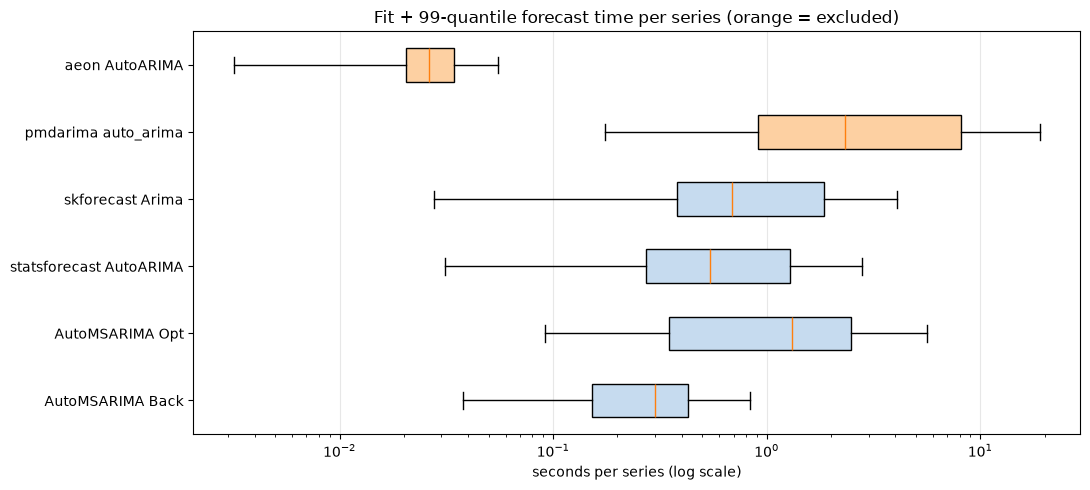

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
order = KEPT + DROPPED
data = [point[row[n], :, 1][np.isfinite(point[row[n], :, 1])] for n in order]
box = ax.boxplot(data, orientation="horizontal", tick_labels=order,
                 showfliers=False, patch_artist=True)
for patch, n in zip(box["boxes"], order):
    patch.set_facecolor("#c6dbef" if n in KEPT else "#fdd0a2")
ax.set(xscale="log", xlabel="seconds per series (log scale)",
       title="Fit + 99-quantile forecast time per series (orange = excluded)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## Feeding the paper's MCB test

The per-series measures behind Tables 6 and 7 and the Nemenyi (MCB) plots are
exported by the scripts in `smooth-paper/scripts/`:

```bash
cd smooth-paper
python3 scripts/01-export-python-measures.py ..     # Python competitors -> Data/python-arima-*.csv
Rscript  scripts/02-export-R-measures.R Data        # smooth + forecast in R -> Data/r-arima-*.csv
Rscript  scripts/03-nemenyi-mcb.R Data Images       # rmcb() -> Images/mcb-arima-*.pdf
```

`01-export-python-measures.py` keeps exactly the Python columns compared above,
so the exclusions decided here are the ones that reach the paper.

In [13]:
data_dir = os.path.join(PAPER, "Data")
for kind in ("python", "r"):
    for measure in ("rmsse", "pinball"):
        path = os.path.join(data_dir, f"{kind}-arima-{measure}.csv")
        if os.path.exists(path):
            frame = pd.read_csv(path)
            print(f"{os.path.basename(path):28s} {frame.shape[0]:5d} series x "
                  f"{frame.shape[1]} methods: {', '.join(frame.columns)}")
        else:
            print(f"{os.path.basename(path):28s} not exported yet")

python-arima-rmsse.csv        5315 series x 2 methods: statsforecast AutoARIMA, skforecast Arima
python-arima-pinball.csv      5315 series x 2 methods: statsforecast AutoARIMA, skforecast Arima
r-arima-rmsse.csv             5315 series x 3 methods: MSARIMA back, MSARIMA opt, forecast arima
r-arima-pinball.csv           5315 series x 3 methods: MSARIMA back, MSARIMA opt, forecast arima
